# Photometry Jupyter Notebook

## Imports

In [1]:
import os
os.environ['BOKEH_ALLOW_WS_ORIGIN'] = ("1p28kn9d2v74i6ilhivhds70odo8uta4sugfufmvcsmi64u4r81g")
print("BOKEH_ALLOW_WS_ORIGIN =", os.environ.get('BOKEH_ALLOW_WS_ORIGIN'))

from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS
import astropy.units as u

import photutils
from photutils.psf import fit_2dgaussian
from photutils.centroids import centroid_2dg
from photutils.aperture import aperture_photometry, CircularAperture, CircularAnnulus
from astroquery.jplhorizons import Horizons

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar

from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import HoverTool
output_notebook()

import warnings
warnings.filterwarnings('ignore')

BOKEH_ALLOW_WS_ORIGIN = 1p28kn9d2v74i6ilhivhds70odo8uta4sugfufmvcsmi64u4r81g


Loading BokehJS ...

## Configuration

In [2]:
# Plotting parameters

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = True
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['figure.dpi'] = 130

In [3]:
# Directory containing reduced FITS files
direc = 'C:/Users/Matylda/Documents/TGP'  # UPDATE THIS PATH

# Image codes for each standard star
codes1 = [167861, 167863, 167866, 167868, 167869, 167870, 167871, 167872, 167874, 167875, 167876, 167877]
codes2 = [167879, 167880, 167881, 167882, 167885, 167886, 167887, 167888, 167889, 167890, 167905, 167906]
codes3 = [167891, 167892, 167893, 167894, 167895, 167896, 167897, 167899, 167900, 167901, 167902, 167903, 167904]

# Image codes for asteroid observations
asteroid_codes = [167137, 167140, 167147, 167148, 167149, 167150, 167152, 167153, 167154, 167155, 167156, 167158, 167159, 167160, 167161, 167162, 167163, 167164, 167165, 167166, 167167, 167168]

# Filter mapping
filter_map = {
    'R': ['r', 'red', 'R'],
    'V': ['v', 'V'],
    'B': ['b', 'blue', 'B'],
    'I': ['i', 'I']
}

# Standard star RA/Dec coordinates (hours, degrees)
# Standard Star 1: RA = 20h 30m 03.4s, Dec = 39° 15' 21"
ss1_ra = (20 + 30/60 + 3.4/3600) * 15  # Convert to degrees
ss1_dec = 39 + 15/60 + 21/3600

# Standard Star 2: RA = 1h 52m 4.29s, Dec = 47° 1' 47.4"
ss2_ra = (1 + 52/60 + 4.29/3600) * 15
ss2_dec = 47 + 1/60 + 47.4/3600

# Standard Star 3: RA = 3h 44m 7s, Dec = 45° 6' 0.2"
ss3_ra = (3 + 44/60 + 7/3600) * 15
ss3_dec = 45 + 6/60 + 0.2/3600

# Asteroid information
asteroid_name = "Belgica"  # UPDATE THIS
observatory_code = "Z63"   # PIRATE observatory code

# Centroid refinement radius (pixels)
centroid_radius_ss1 = 20
centroid_radius_ss2 = 25
centroid_radius_ss3 = 35
centroid_radius_asteroid = 10

## Utility Functions

In [4]:
def snr(data, ap, an):
    """
    Calculate signal-to-noise ratio for aperture photometry.
    
    Parameters:
    -----------
    data : array
        Image data
    ap : CircularAperture
        Aperture for photometry
    an : CircularAnnulus
        Annulus for sky background estimation
    
    Returns:
    --------
    float : Signal-to-noise ratio
    """
    phot = aperture_photometry(data, ap)
    flux_ap = phot['aperture_sum'][0]

    annulus_masks = an.to_mask(method='center')
    annulus_data = annulus_masks.multiply(data)
    sky_pixels = annulus_data[annulus_masks.data > 0]
    sky_mean = np.mean(sky_pixels)
    sky_std = np.std(sky_pixels)

    n_pix = ap.area
    flux = flux_ap - sky_mean * n_pix

    gain = 1.39
    flux_e = flux * gain
    sigma_sky_e = sky_std * gain
    noise = np.sqrt(flux_e + n_pix * sigma_sky_e**2)

    return flux_e / noise

def normalize_filter_name(filter_str, filter_map):
    """
    Normalize filter name to standard single-letter format.
    
    Parameters:
    -----------
    filter_str : str
        Filter name from FITS header
    filter_map : dict
        Mapping of filter variations to standard names
    
    Returns:
    --------
    str : Normalized filter name
    """
    for standard, variants in filter_map.items():
        if filter_str in variants:
            return standard
    return filter_str

def get_airmass(header):
    """
    Extract airmass from FITS header, calculating if necessary.
    
    Parameters:
    -----------
    header : astropy.io.fits.Header
        FITS header
    
    Returns:
    --------
    float : Airmass value
    """
    if 'AIRMASS' in header:
        return header['AIRMASS']
    elif 'ALT-REF' in header:
        alt = header['ALT-REF']
        if alt > 0:
            zenith = 90 - alt
            return 1.0 / np.cos(np.radians(zenith))
    return 1.0  # Default if can't determine

def flux_to_mag(norm_flux):
    """
    Convert normalized flux to instrumental magnitude.
    
    Parameters:
    -----------
    norm_flux : float
        Flux normalized by exposure time
    
    Returns:
    --------
    float : Instrumental magnitude
    """
    return -2.5 * np.log10(norm_flux)

def error_in_mag(standardFlux, skyFlux):
    """
    Calculate magnitude error from photon statistics.
    
    Parameters:
    -----------
    standardFlux : float
        Source flux
    skyFlux : float
        Sky background flux
    
    Returns:
    --------
    float : Magnitude error
    """
    C = standardFlux
    dC = np.sqrt(standardFlux + skyFlux)
    return (-2.5 / np.log(10)) * (dC / C)

## Location Finding Functions

These functions find and refine the pixel coordinates of stars and asteroids using:
1. WCS transformation from RA/Dec (or JPL Horizons for asteroids)
2. 2D Gaussian centroid refinement

In [16]:
def find_star_locations(codes, ra, dec, data_dir, ref_code=None, centroid_radius=25, visualize=True):
    """
    Find and refine star locations using WCS and centroid refinement.
    
    Parameters:
    -----------
    codes : list
        List of image codes
    ra : float
        Right ascension in degrees
    dec : float
        Declination in degrees
    data_dir : str
        Directory containing FITS files
    ref_code : int, optional
        Reference image code for missing WCS headers
    centroid_radius : int
        Radius for centroid cutout in pixels
    visualize : bool
        Whether to display visualization
    
    Returns:
    --------
    tuple : (data, locations, headers)
        - data: list of image arrays
        - locations: list of (x, y) refined pixel coordinates
        - headers: list of FITS headers
    """
    
    # Load reference WCS if provided
    ref_wcs = None
    if ref_code is not None:
        with fits.open(f'{data_dir}/{ref_code}.fits') as ref:
            ref_hdr = ref[0].header.copy()
            ref_wcs = WCS(ref_hdr)
    
    # First pass: get approximate locations
    data = []
    locs_approx = []
    hdrs = []
    
    for c in codes:
        with fits.open(f'{data_dir}/{c}.fits') as file:
            hdr = file[0].header.copy()
            
            # If CRPIX is missing, copy WCS from reference
            if 'CRPIX1' not in hdr or 'CRPIX2' not in hdr:
                hdr.update(ref_wcs.to_header())
            
            # Correct for cropping the raw data
            hdr['CRPIX1'] -= 21
            hdr['CRPIX2'] -= 21
            wcs = WCS(hdr)
            
            # Convert RA/Dec to pixel coordinates
            px, py = wcs.world_to_pixel_values(ra, dec)
            
            image = file[0].data
            data.append(image)
            locs_approx.append((px, py))
            hdrs.append(hdr)
    
    # Second pass: refine locations using 2D Gaussian centroid
    r = centroid_radius
    locs_refined = []
    
    if visualize:
        n_images = len(data)
        ncols = min(4, n_images)
        nrows = (n_images + ncols - 1) // ncols
        fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
        if n_images == 1:
            axs = [axs]
        else:
            axs = axs.flatten() if nrows > 1 else axs
    
    for i, (d, l) in enumerate(zip(data, locs_approx)):
        x0, y0 = int(np.round(l[0])), int(np.round(l[1]))
        
        # Extract cutout around approximate location
        cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]
        
        # Find centroid in cutout
        x_c, y_c = centroid_2dg(cutout)
        
        # Convert back to full image coordinates
        x_refined = x0 - r + x_c
        y_refined = y0 - r + y_c
        
        locs_refined.append((x_refined, y_refined))
        
        if visualize:
            vn, vx = np.percentile(d, [5, 99])
            axs[i].imshow(d, cmap="gray", vmin=vn, vmax=vx)
            axs[i].add_patch(Circle((x_refined, y_refined), radius=10, 
                                   edgecolor="red", facecolor="none", linewidth=2))
            axs[i].add_patch(Circle((x0, y0), radius=10, 
                                   edgecolor="blue", facecolor="none", linewidth=2))
            axs[i].set_xlim(x_refined-25, x_refined+25)
            axs[i].set_ylim(y_refined-25, y_refined+25)
            axs[i].set_title(f'Image {codes[i]}')
    
    if visualize:
        # Hide unused subplots
        for i in range(len(data), len(axs)):
            axs[i].axis('off')
        fig.tight_layout()
        plt.show()
    
    return data, locs_refined, hdrs

def find_asteroid_locations(codes, asteroid_name, observatory_code, data_dirs, 
                           centroid_radius=10, visualize=True):
    """
    Find and refine asteroid locations using JPL Horizons ephemeris.
    
    Parameters:
    -----------
    codes : list
        List of image codes
    asteroid_name : str
        Name of the asteroid
    observatory_code : str
        IAU observatory code
    data_dirs : dict
        Dictionary mapping special codes to alternate directories
    centroid_radius : int
        Radius for centroid cutout in pixels
    visualize : bool
        Whether to display visualization
    
    Returns:
    --------
    tuple : (data, locations, headers)
        - data: list of image arrays
        - locations: list of (x, y) refined pixel coordinates
        - headers: list of FITS headers
    """
    # First pass: get approximate locations using Horizons
    data = []
    locs_approx = []
    hdrs = []
    
    for c in codes:
        # Determine which directory to use
        data_dir = data_dirs.get(c, data_dirs['default'])
        
        with fits.open(f'{data_dir}/{c}.fits') as file:
            hdr = file[0].header.copy()
            
            # Query JPL Horizons for ephemeris
            obs_time = Time(hdr["DATE-OBS"], format="isot", scale="utc")
            obj = Horizons(id=asteroid_name, location=observatory_code, epochs=obs_time.jd)
            eph = obj.ephemerides()
            ra = eph["RA"][0]
            dec = eph["DEC"][0]
            
            # Correct for cropping the raw data
            hdr['CRPIX1'] -= 21
            hdr['CRPIX2'] -= 21
            wcs = WCS(hdr)
            
            # Convert RA/Dec to pixel coordinates
            px, py = wcs.world_to_pixel_values(ra, dec)
            
            image = file[0].data
            data.append(image)
            locs_approx.append((px, py))
            hdrs.append(hdr)
    
    # Second pass: refine locations using 2D Gaussian centroid
    r = centroid_radius
    locs_refined = []
    
    if visualize:
        n_images = len(data)
        ncols = min(5, n_images)
        nrows = (n_images + ncols - 1) // ncols
        fig, axs = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
        if n_images == 1:
            axs = [axs]
        else:
            axs = axs.flatten() if nrows > 1 else axs
    
    for i, (d, l) in enumerate(zip(data, locs_approx)):
        x0, y0 = int(np.round(l[0])), int(np.round(l[1]))
        
        # Extract cutout around approximate location
        cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]
        
        # Find centroid in cutout
        x_c, y_c = centroid_2dg(cutout)
        
        # Convert back to full image coordinates
        x_refined = x0 - r + x_c
        y_refined = y0 - r + y_c
        
        locs_refined.append((x_refined, y_refined))
        
        if visualize:
            vn, vx = np.percentile(d, [5, 99])
            axs[i].imshow(d, cmap="gray", vmin=vn, vmax=vx)
            axs[i].add_patch(Circle((x_refined, y_refined), radius=6, 
                                   edgecolor="red", facecolor="none", linewidth=2))
            axs[i].add_patch(Circle((x0, y0), radius=6, 
                                   edgecolor="blue", facecolor="none", linewidth=2))
            axs[i].set_xlim(x_refined-10, x_refined+10)
            axs[i].set_ylim(y_refined-10, y_refined+10)
            axs[i].set_title(f'{codes[i]}')
            axs[i].axis('off')
    
    if visualize:
        # Hide unused subplots
        for i in range(len(data), len(axs)):
            axs[i].axis('off')
        fig.tight_layout()
        plt.show()
    
    return data, locs_refined, hdrs

## Find Star and Asteroid Locations

Run this section to automatically find and refine all source locations.

Finding Standard Star 1 locations...


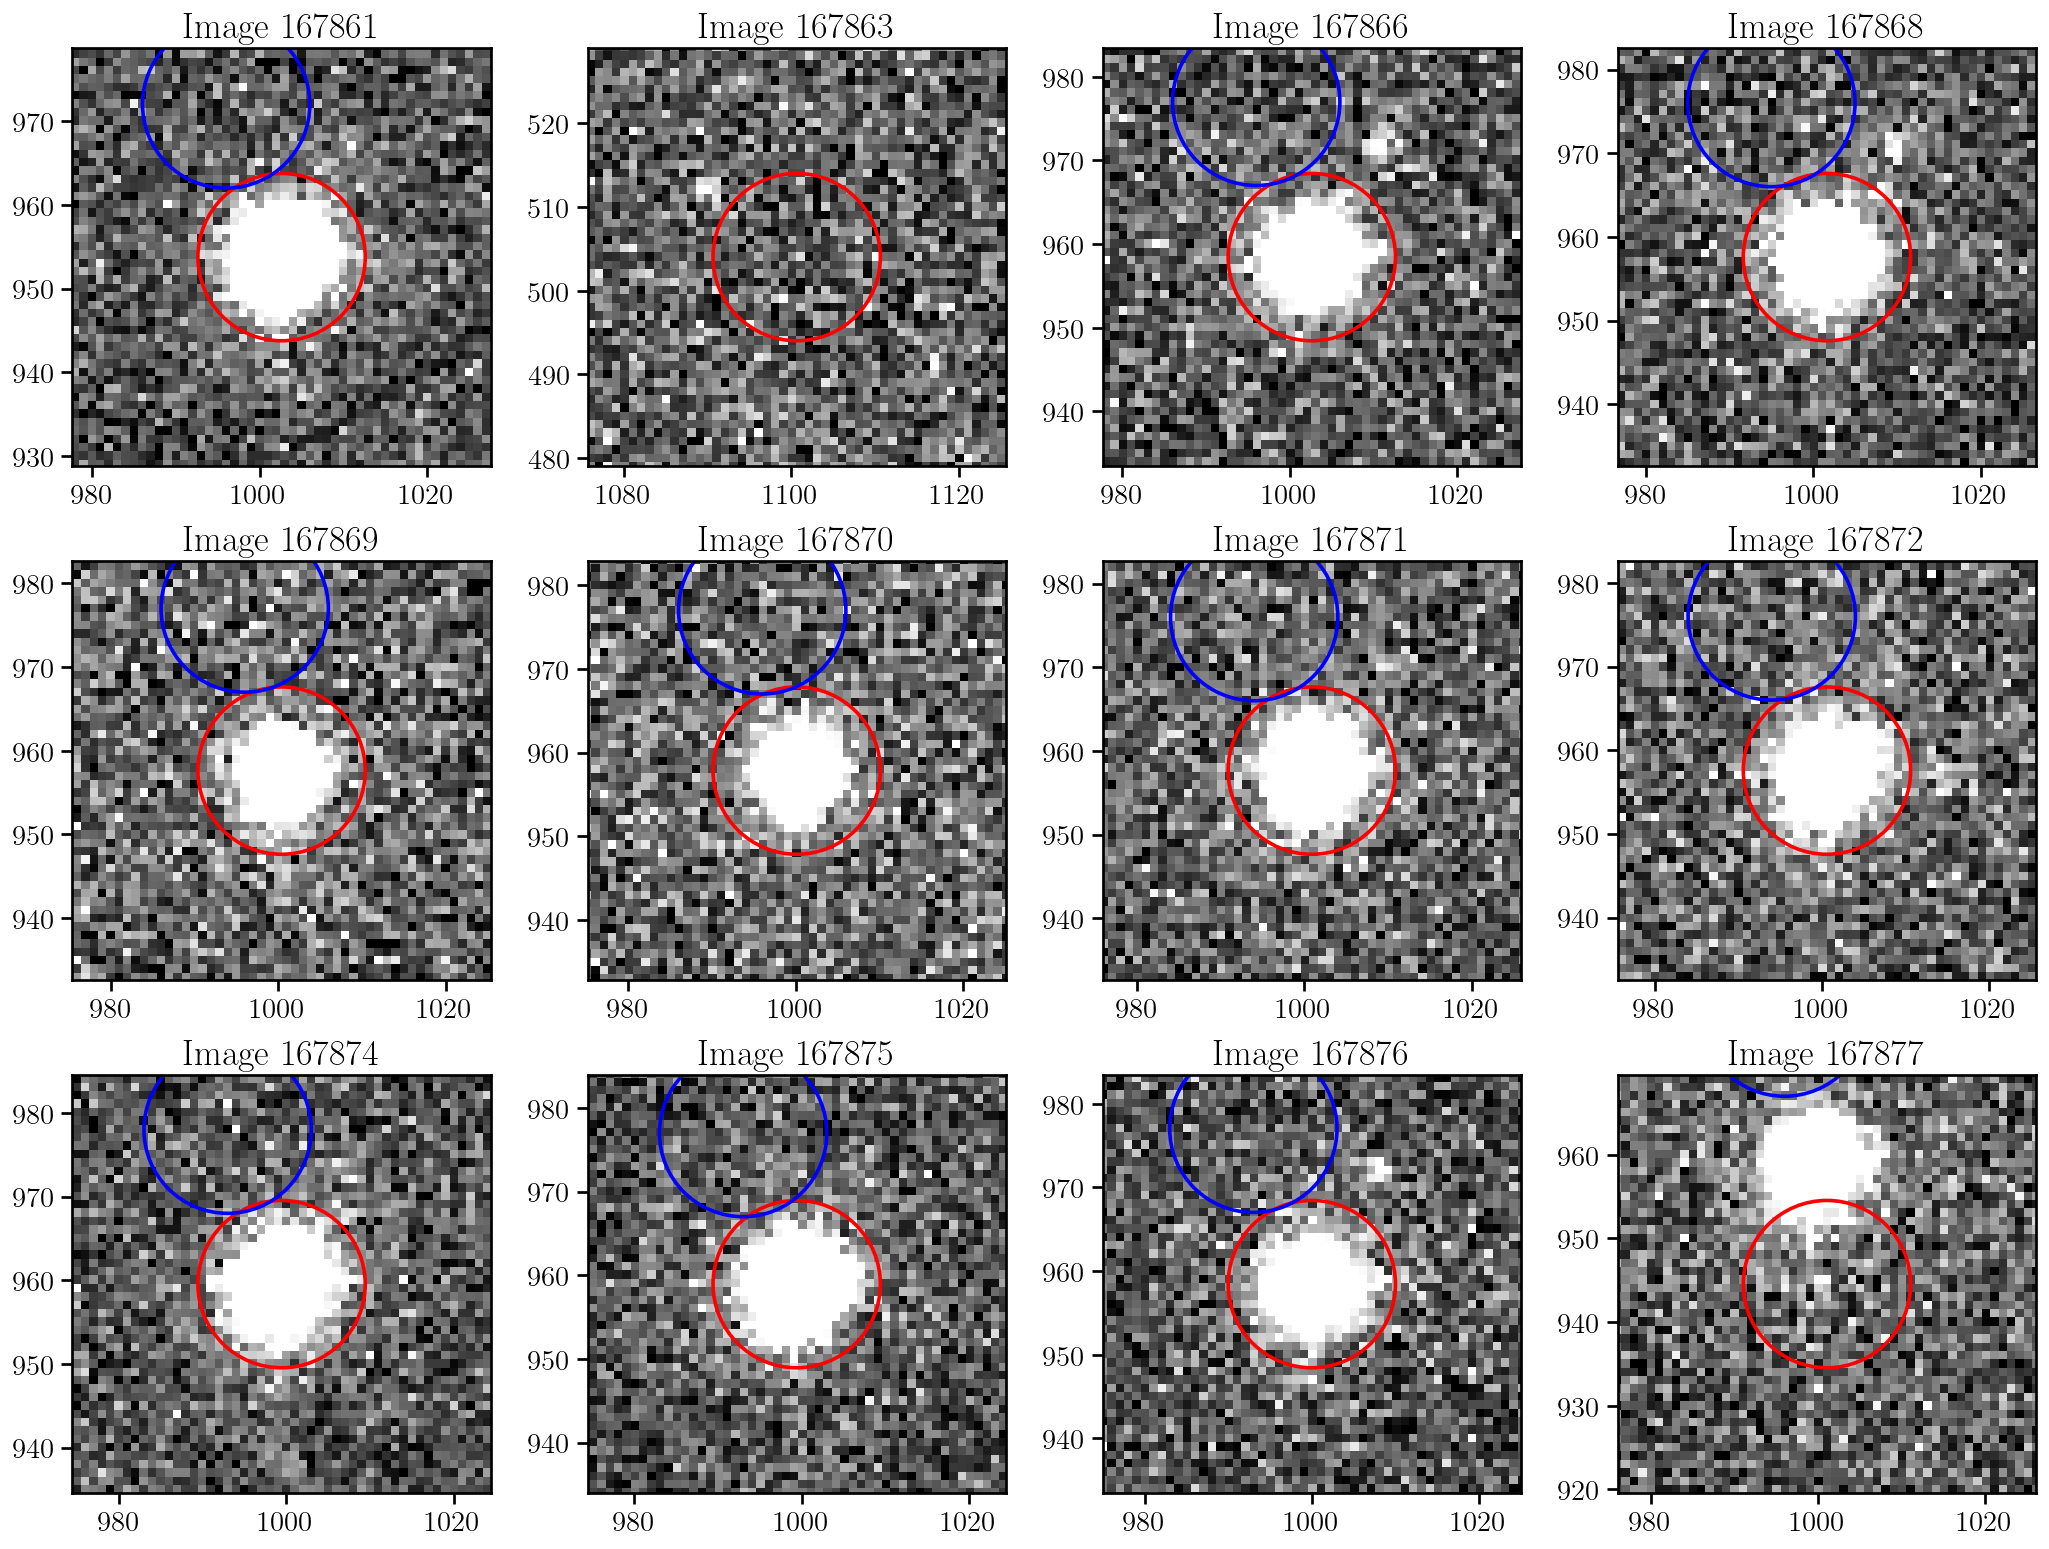

Found 12 locations for Standard Star 1


In [20]:
print("Finding Standard Star 1 locations...")
data1, locs1, hdrs1 = find_star_locations(
    codes1, ss1_ra, ss1_dec, 
    f'{direc}/Reduced_data_day3',
    ref_code=167866,
    centroid_radius=centroid_radius_ss1,
    visualize=True
)
print(f"Found {len(locs1)} locations for Standard Star 1")

Finding Standard Star 2 locations...


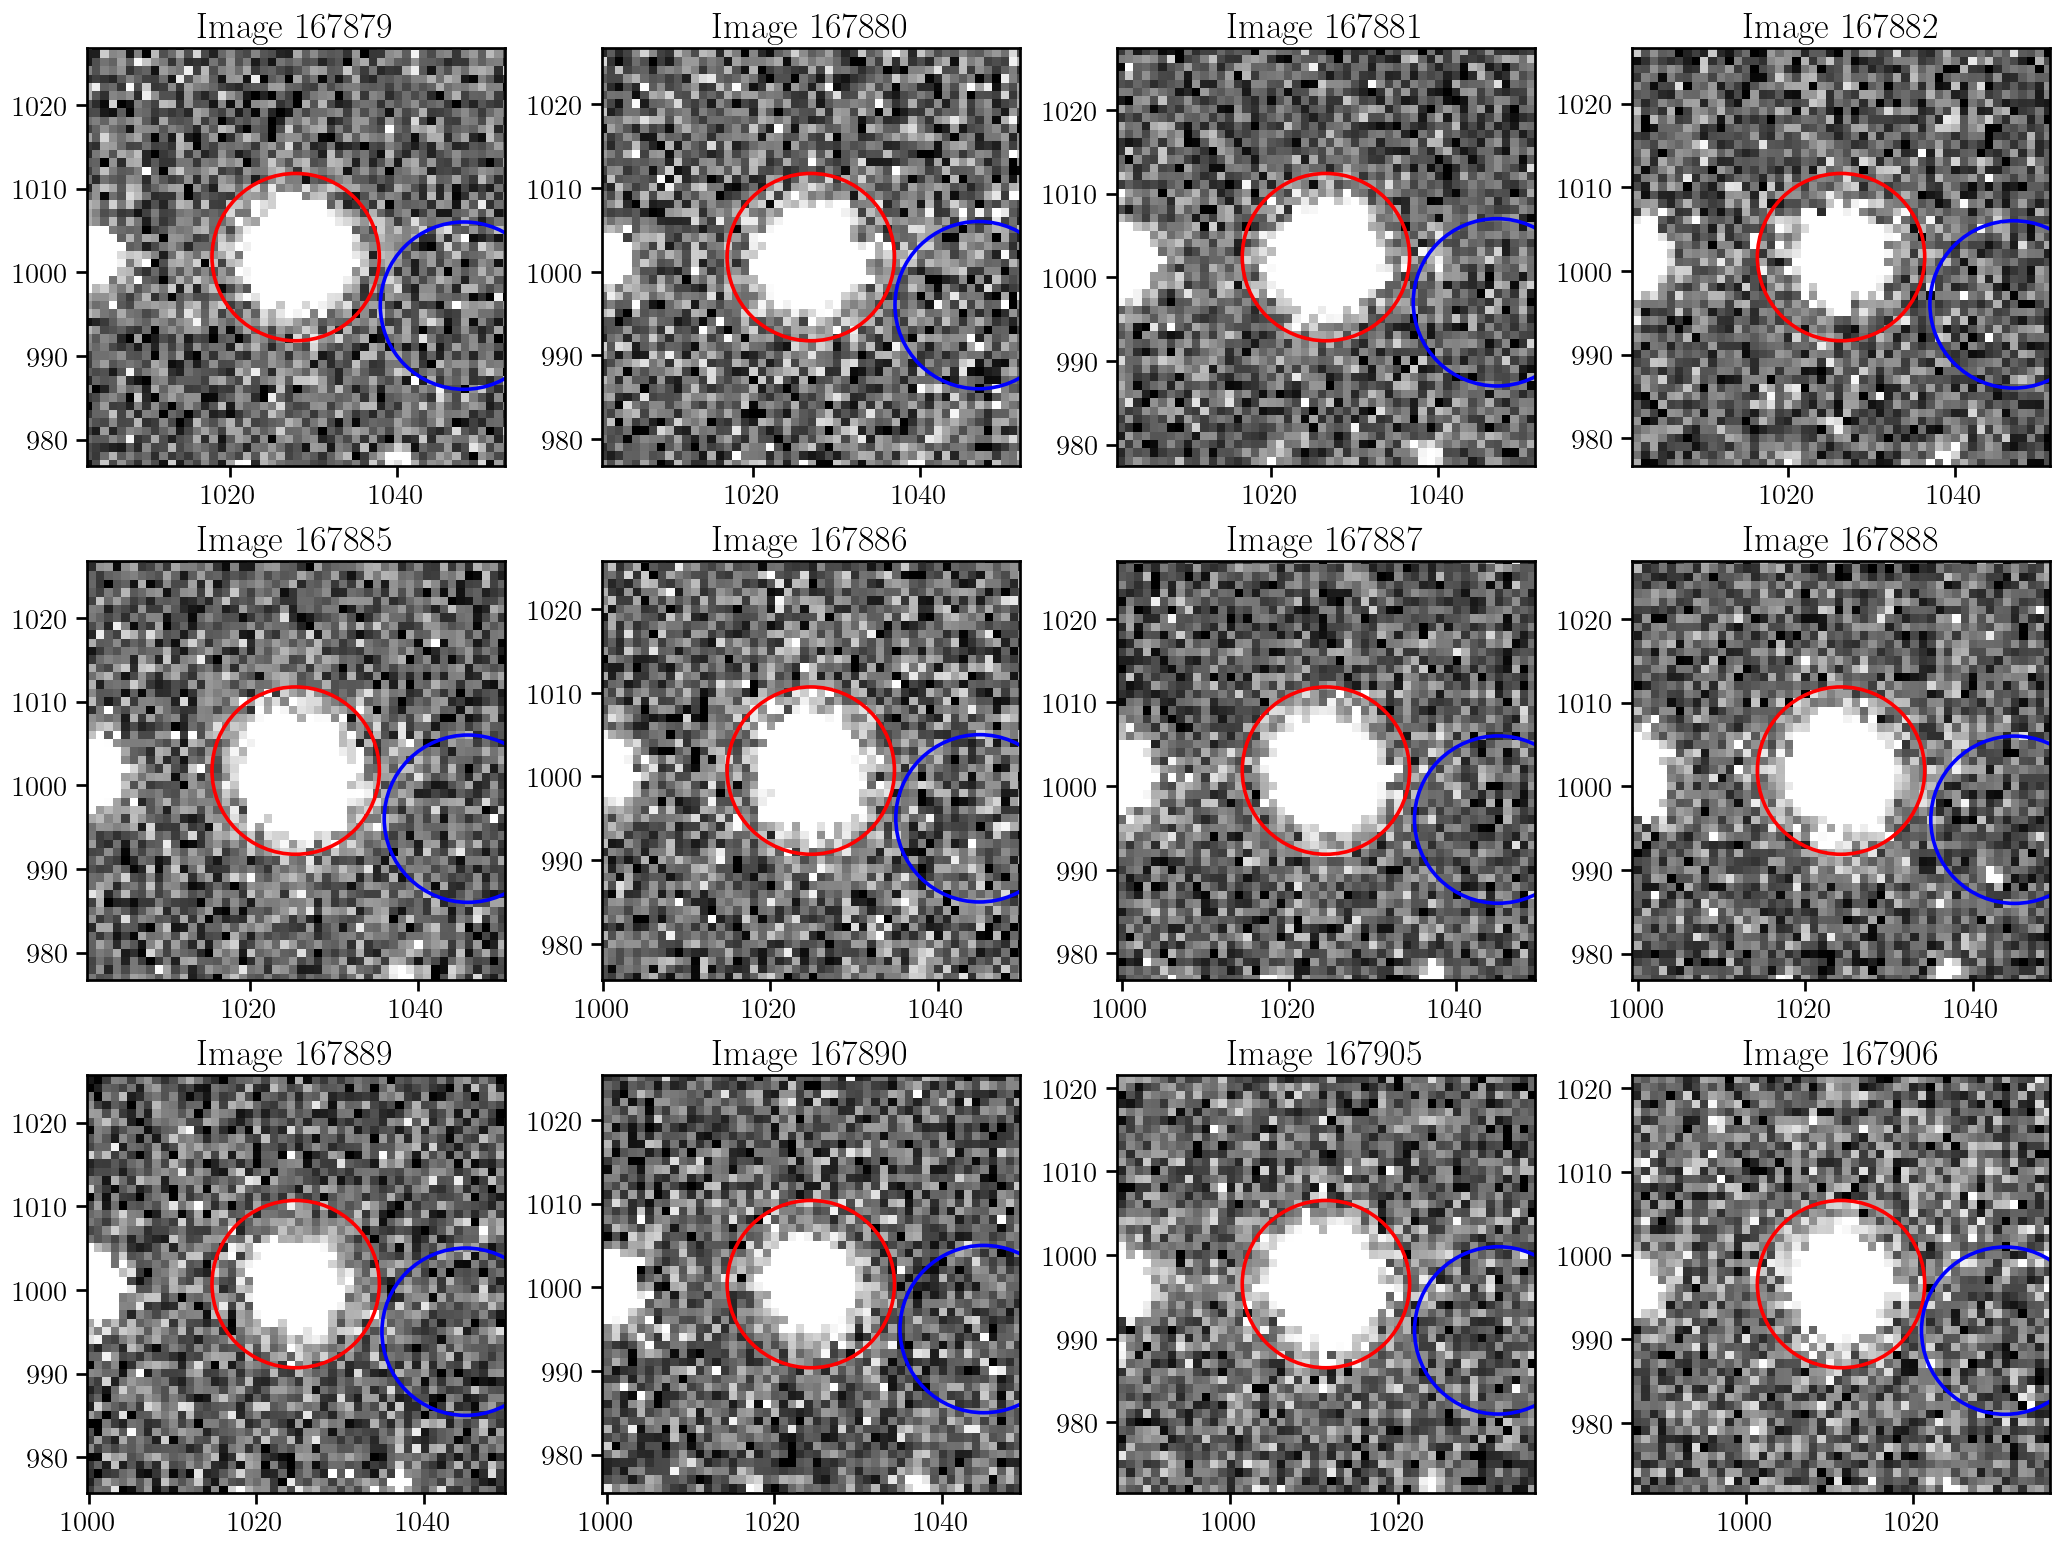

Found 12 locations for Standard Star 2


In [10]:
print("Finding Standard Star 2 locations...")
data2, locs2, hdrs2 = find_star_locations(
    codes2, ss2_ra, ss2_dec,
    f'{direc}/Reduced_data_day3',
    ref_code=167879,  # Reference image for missing WCS
    centroid_radius=centroid_radius_ss2,
    visualize=True
)
print(f"Found {len(locs2)} locations for Standard Star 2")

Finding Standard Star 3 locations...


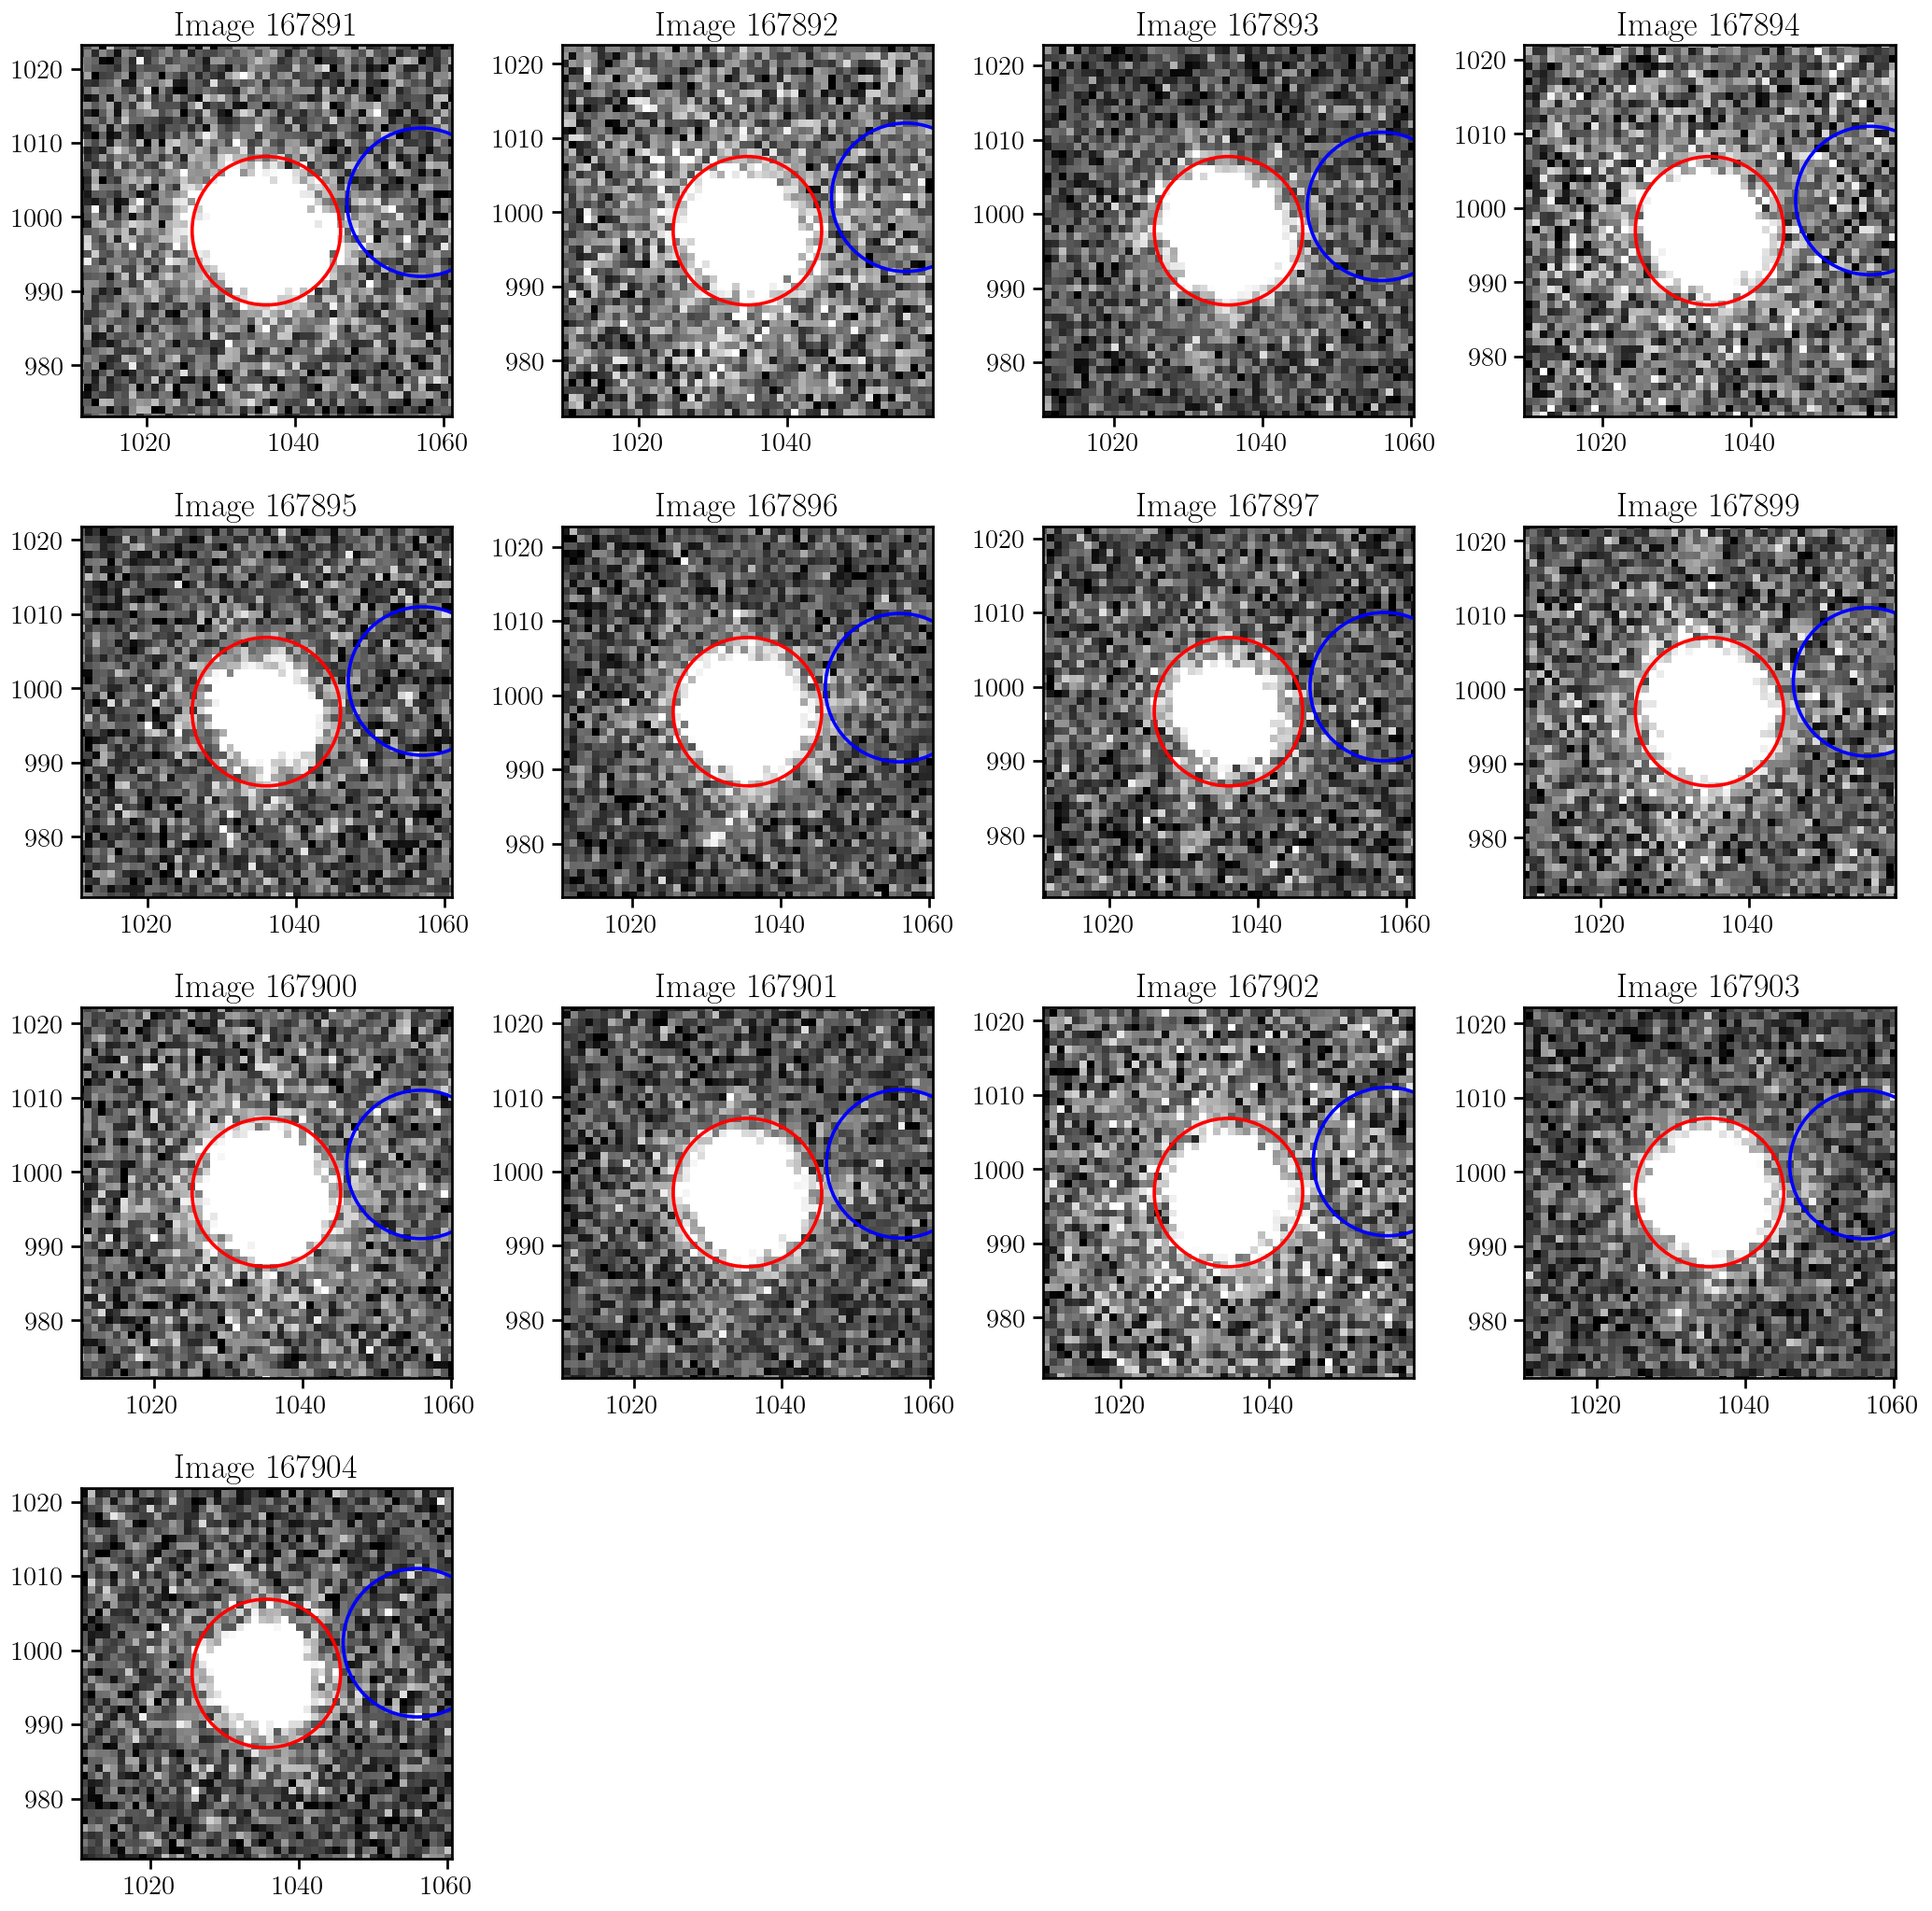

Found 13 locations for Standard Star 3


In [19]:
print("Finding Standard Star 3 locations...")
data3, locs3, hdrs3 = find_star_locations(
    codes3, ss3_ra, ss3_dec,
    f'{direc}/Reduced_data_day3',
    ref_code=167891,  # Reference image for missing WCS
    centroid_radius=centroid_radius_ss3,
    visualize=True
)
print(f"Found {len(locs3)} locations for Standard Star 3")

In [ ]:
print(f"Finding {asteroid_name} locations using JPL Horizons...")

# Define which images are in alternate directories
asteroid_data_dirs = {
    'default': f'{direc}/Reduced_data_day2',
    167153: f'{direc}/Reduced_data_I',
    167162: f'{direc}/Reduced_data_I',
    167168: f'{direc}/Reduced_data_I'
}

data_asteroid, locs_asteroid, hdrs_asteroid = find_asteroid_locations(
    asteroid_codes, asteroid_name, observatory_code,
    asteroid_data_dirs,
    centroid_radius=centroid_radius_asteroid,
    visualize=True
)
print(f"Found {len(locs_asteroid)} locations for {asteroid_name}")

## Aperture Optimization

In [ ]:
def optimize_apertures(data, locations, title="Aperture Optimization"):
    """
    Optimize aperture radius for each image to maximize SNR.
    
    Parameters:
    -----------
    data : list
        List of image arrays
    locations : list
        List of (x, y) pixel coordinates
    title : str
        Title for the plot
    
    Returns:
    --------
    list : Optimal aperture radii for each image
    """
    n_images = len(data)
    ncols = min(4, n_images)
    nrows = (n_images + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    if n_images == 1:
        axs = [axs]
    else:
        axs = axs.flatten() if nrows > 1 else axs
    
    optimal_radii = []
    
    for i, (d, loc, ax) in enumerate(zip(data, locations, axs)):
        def ap_opt(r):
            an1 = 2 * r
            an2 = 3 * r
            ap = CircularAperture(loc, r=r)
            an = CircularAnnulus(loc, r_in=an1, r_out=an2)
            return -snr(d, ap, an)
        
        # Rough search
        aps = np.linspace(0.5, 20, 20)
        rough_peak = aps[np.argmax([-ap_opt(ap) for ap in aps])]
        
        # Fine optimization
        res = minimize_scalar(ap_opt, bounds=(rough_peak-2, rough_peak+2))
        optimal_radii.append(res.x)
        
        # Plot
        ax.plot(aps, [-ap_opt(ap) for ap in aps], c="k")
        ax.scatter(res.x, -res.fun, c="r", s=100, zorder=5)
        ax.set_title(f"r = {res.x:.2f} px\nSNR = {-res.fun:.1f}")
        ax.set_xlabel("Aperture radius (px)")
        ax.set_ylabel("SNR")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(data), len(axs)):
        axs[i].axis('off')
    
    fig.suptitle(title, fontsize=14, y=1.00)
    fig.tight_layout()
    plt.show()
    
    return optimal_radii

print("Optimizing apertures for Standard Star 1...")
optims1 = optimize_apertures(data1, locs1, "Standard Star 1 - Aperture Optimization")

print("\nOptimizing apertures for Standard Star 2...")
optims2 = optimize_apertures(data2, locs2, "Standard Star 2 - Aperture Optimization")

print("\nOptimizing apertures for Standard Star 3...")
optims3 = optimize_apertures(data3, locs3, "Standard Star 3 - Aperture Optimization")

print(f"\nOptimizing apertures for {asteroid_name}...")
optims_asteroid = optimize_apertures(data_asteroid, locs_asteroid, f"{asteroid_name} - Aperture Optimization")

## Perform Photometry

In [ ]:
def perform_photometry(codes, data, locations, optimal_radii, data_dir, object_name="object"):
    """
    Perform aperture photometry on all images.
    
    Parameters:
    -----------
    codes : list
        Image codes
    data : list
        Image data arrays
    locations : list
        Source pixel coordinates
    optimal_radii : list
        Optimized aperture radii
    data_dir : str or dict
        Directory or dict of directories containing FITS files
    object_name : str
        Name of object for display
    
    Returns:
    --------
    dict : Photometry results keyed by image code
    """
    results = {}
    
    for i, c in enumerate(codes):
        # Determine data directory
        if isinstance(data_dir, dict):
            dir_path = data_dir.get(c, data_dir['default'])
        else:
            dir_path = data_dir
        
        # Load image
        with fits.open(f'{dir_path}/{c}.fits') as file:
            hdr = file[0].header.copy()
            image = file[0].data
        
        # Define apertures
        r_ap = optimal_radii[i]
        r_sky_in = r_ap * 1.5
        r_sky_out = r_ap * 2.0
        
        ap = CircularAperture(locations[i], r=r_ap)
        an = CircularAnnulus(locations[i], r_in=r_sky_in, r_out=r_sky_out)
        
        # Sky background
        sky_phot = aperture_photometry(image, an)
        sky_area = np.pi * (r_sky_out**2 - r_sky_in**2)
        sky_flux = sky_phot['aperture_sum'].value
        mean_sky = sky_flux / sky_area
        
        # Source photometry
        src_phot = aperture_photometry(image - mean_sky, ap)
        src_flux = src_phot['aperture_sum'].value
        
        # Calculate magnitude
        exposure = hdr['EXPOSURE']
        norm_flux = src_flux / exposure
        magnitude = flux_to_mag(norm_flux)
        mag_error = error_in_mag(src_flux, sky_flux)
        
        # Get filter and airmass
        filt = normalize_filter_name(hdr.get('FILTER', 'UNKNOWN'), filter_map)
        airmass = get_airmass(hdr)
        
        # Store results
        results[c] = {
            'magnitude': magnitude,
            'error': mag_error,
            'filter': filt,
            'airmass': airmass,
            'exposure': exposure,
            'flux': src_flux,
            'norm_flux': norm_flux
        }
        
        print(f'{object_name} image {c}: mag = {magnitude[0]:.4f} ± {abs(mag_error[0]):.4f}, '
              f'filter = {filt}, airmass = {airmass:.3f}')
    
    return results

In [ ]:
print("=" * 60)
print("STANDARD STAR 1 PHOTOMETRY")
print("=" * 60)
ss1_results = perform_photometry(
    codes1, data1, locs1, optims1,
    f'{direc}/Reduced_data_day3',
    object_name="SS1"
)

print("\n" + "=" * 60)
print("STANDARD STAR 2 PHOTOMETRY")
print("=" * 60)
ss2_results = perform_photometry(
    codes2, data2, locs2, optims2,
    f'{direc}/Reduced_data_day3',
    object_name="SS2"
)

print("\n" + "=" * 60)
print("STANDARD STAR 3 PHOTOMETRY")
print("=" * 60)
ss3_results = perform_photometry(
    codes3, data3, locs3, optims3,
    f'{direc}/Reduced_data_day3',
    object_name="SS3"
)

print("\n" + "=" * 60)
print(f"{asteroid_name.upper()} PHOTOMETRY")
print("=" * 60)
asteroid_results = perform_photometry(
    asteroid_codes, data_asteroid, locs_asteroid, optims_asteroid,
    asteroid_data_dirs,
    object_name=asteroid_name
)

## Calibration

Calculate extinction coefficients and zero points for each filter.

In [ ]:
def calculate_extinction_and_zeropoint(results, m_true=1.0):
    """
    Calculate extinction coefficient and zero point for each filter.
    
    Parameters:
    -----------
    results : dict
        Photometry results
    m_true : float
        True magnitude of standard star
    
    Returns:
    --------
    tuple : (extinction_dict, zeropoint_dict)
    """
    # Organize by filter
    by_filter = {}
    for code, data in results.items():
        filt = data['filter']
        if filt not in by_filter:
            by_filter[filt] = {'mags': [], 'airmass': []}
        by_filter[filt]['mags'].append(data['magnitude'][0])
        by_filter[filt]['airmass'].append(data['airmass'])
    
    extinction = {}
    zeropoint = {}
    
    for filt, data in by_filter.items():
        mags = np.array(data['mags'])
        airmass = np.array(data['airmass'])
        
        # Linear fit: m_inst = k * X + const
        if len(mags) > 1:
            coeffs = np.polyfit(airmass, mags, 1)
            k = coeffs[0]  # extinction coefficient
            
            # Zero point: ZP = m_true - <m_inst> - k * <X>
            zp = m_true - np.mean(mags) - k * np.mean(airmass)
        else:
            k = 0.0
            zp = m_true - mags[0]
        
        extinction[filt] = k
        zeropoint[filt] = zp
    
    return extinction, zeropoint

# Calculate for each standard star
ss1_extinction, ss1_zeropoints = calculate_extinction_and_zeropoint(ss1_results)
ss2_extinction, ss2_zeropoints = calculate_extinction_and_zeropoint(ss2_results)
ss3_extinction, ss3_zeropoints = calculate_extinction_and_zeropoint(ss3_results)

# Create summary table
all_filters = set(list(ss1_extinction.keys()) + list(ss2_extinction.keys()) + list(ss3_extinction.keys()))
summary_data = []

for filt in sorted(all_filters):
    row = {'Filter': filt}
    
    if ss1_extinction.get(filt) is not None:
        row['SS1_k'] = f"{ss1_extinction[filt]:.4f}"
        row['SS1_ZP'] = f"{ss1_zeropoints[filt]:.4f}"
    else:
        row['SS1_k'] = 'N/A'
        row['SS1_ZP'] = 'N/A'
    
    if ss2_extinction.get(filt) is not None:
        row['SS2_k'] = f"{ss2_extinction[filt]:.4f}"
        row['SS2_ZP'] = f"{ss2_zeropoints[filt]:.4f}"
    else:
        row['SS2_k'] = 'N/A'
        row['SS2_ZP'] = 'N/A'
    
    if ss3_extinction.get(filt) is not None:
        row['SS3_k'] = f"{ss3_extinction[filt]:.4f}"
        row['SS3_ZP'] = f"{ss3_zeropoints[filt]:.4f}"
    else:
        row['SS3_k'] = 'N/A'
        row['SS3_ZP'] = 'N/A'
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n=== Calibration Summary ===")
print(summary_df.to_string(index=False))
print("\nNote: Zero points calculated using placeholder m_true = 1.0")
print("TODO: Update with actual standard star magnitudes for accurate zero points")